Palmistry Image Dataset

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="93bVHJBLDPtCueJ6QikY")
project = rf.workspace("docseg").project("palmistry-kp")
version = project.version(6)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to palmistry-kp-6 in coco:: 100%|██████████| 7120/7120 [00:00<00:00, 8394.15it/s]


### Palm Line Detection, Feature Extraction, and Classification

This section will demonstrate how to address the requested tasks using the downloaded 'Palmistry Image Dataset'. We'll begin by loading the COCO annotations and visualizing an example to understand the available features (keypoints representing palm lines). Then, we'll discuss how these features can be used for classification.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.0 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to palmistry-kp-6 in coco:: 100%|██████████| 7120/7120 [00:01<00:00, 6285.30it/s]


Dataset downloaded to: /content/palmistry-kp-6
Contents of /content/palmistry-kp-6: ['valid', 'train', 'README.roboflow.txt', 'test', 'README.dataset.txt']

Loading annotations from: /content/palmistry-kp-6/train/_annotations.coco.json
Loaded 4979 images and 19902 annotations for the training set.

Demonstrating 'Palm line detection' and 'Palm feature extraction' for image: Hand_0006393_jpg.rf.2c02fdfb750c80bdf2fb61b952543ea9.jpg


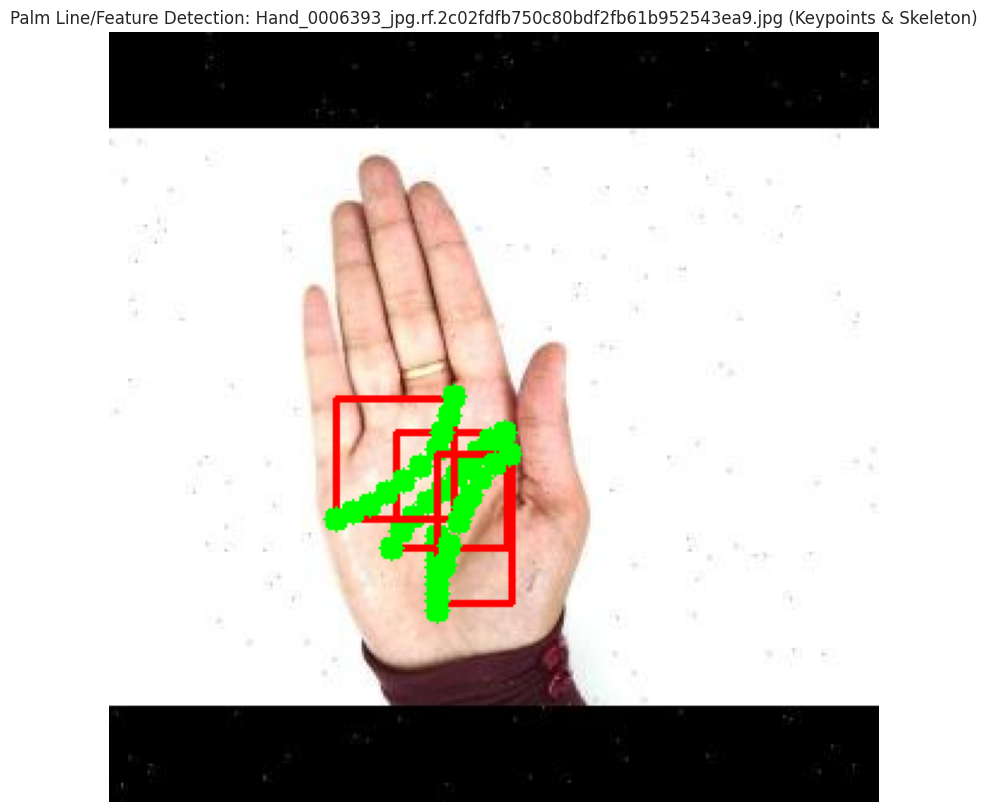


--- Explanation: Palm Feature Extraction ---
The visualized keypoints and their connections (skeleton) directly represent the 'palm lines' and 'palm features' available in this dataset. These keypoints define the structure and significant points of the palm lines.
For *feature extraction*, you can derive various numerical attributes from these keypoints, such as:
1. **Raw Keypoint Coordinates**: A flat array of all (x, y) coordinates for each detected palm instance (e.g., `[kp1_x, kp1_y, kp2_x, kp2_y, ...]`).
2. **Relative Keypoint Positions**: Normalized coordinates (relative to palm bounding box or image size) or distances/angles between specific pairs of keypoints (e.g., length of life line, angle between heart and head line). This makes features robust to scale and translation changes.
3. **Line Properties**: Calculate lengths, curvatures, and orientations of the lines formed by connected keypoints.

--- Explanation: Palm Classification ---
Once these features are extracted from t

In [ ]:
import os
import json
import cv2 # OpenCV for image processing and drawing
import numpy as np
import matplotlib.pyplot as plt

# Install roboflow to ensure it's available
!pip install -q roboflow

# Re-initialize Roboflow and download the dataset to ensure 'dataset' is defined
# This ensures the cell is self-contained and robust to kernel resets or out-of-order execution
from roboflow import Roboflow
rf = Roboflow(api_key="93bVHJBLDPtCueJ6QikY")
project = rf.workspace("docseg").project("palmistry-kp")
version = project.version(6)
dataset = version.download("coco") # Ensure this matches the format downloaded previously

# Get the dataset location from the Roboflow object
dataset_dir = dataset.location
print(f"Dataset downloaded to: {dataset_dir}")

# List contents of the dataset directory to understand its structure
print(f"Contents of {dataset_dir}: {os.listdir(dataset_dir)}")

# Assuming a common COCO dataset structure: annotations are in a JSON file within subdirectories (train/valid/test)
train_annotations_path = os.path.join(dataset_dir, 'train', '_annotations.coco.json')
train_images_dir = os.path.join(dataset_dir, 'train')

# Check if the annotation file exists
if not os.path.exists(train_annotations_path):
    print(f"Warning: COCO annotation file not found at {train_annotations_path}. Please verify the downloaded dataset structure.")
else:
    print(f"\nLoading annotations from: {train_annotations_path}")
    with open(train_annotations_path, 'r') as f:
        coco_data = json.load(f)

    print(f"Loaded {len(coco_data['images'])} images and {len(coco_data['annotations'])} annotations for the training set.")

    # --- Palm line detection & Palm feature extraction (Visualization) ---
    if coco_data['images'] and coco_data['annotations']:
        # Get the first image and its annotations for demonstration
        img_info = coco_data['images'][0]
        img_filename = img_info['file_name']
        img_id = img_info['id']

        # Load the image using OpenCV
        img_path = os.path.join(train_images_dir, img_filename)
        image = cv2.imread(img_path)
        if image is None:
            print(f"Error: Could not load image from {img_path}. Skipping visualization.")
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib display

            # Find annotations (keypoints) for this specific image
            image_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]

            if image_annotations:
                print(f"\nDemonstrating 'Palm line detection' and 'Palm feature extraction' for image: {img_filename}")
                display_image = image.copy() # Make a copy to draw on

                # Define colors for keypoints and lines
                keypoint_color = (0, 255, 0) # Green
                skeleton_color = (255, 0, 255) # Magenta
                bbox_color = (255, 0, 0) # Red

                # Get keypoint labels and skeleton from categories (if defined in COCO JSON)
                keypoint_labels = []
                skeleton_connections = []
                if 'categories' in coco_data and coco_data['categories']:
                    # Assuming there's typically one category for this type of dataset
                    category = coco_data['categories'][0]
                    if 'keypoints' in category:
                        keypoint_labels = category['keypoints']
                    if 'skeleton' in category:
                        skeleton_connections = category['skeleton']

                for ann in image_annotations:
                    # Draw bounding box if available
                    if 'bbox' in ann:
                        x, y, w, h = [int(b) for b in ann['bbox']]
                        cv2.rectangle(display_image, (x, y), (x + w, y + h), bbox_color, 2)

                    # Draw keypoints and skeleton lines
                    if 'keypoints' in ann and ann['keypoints']:
                        keypoints = np.array(ann['keypoints']).reshape(-1, 3) # (x, y, visibility)

                        # Draw keypoints
                        for i, kp in enumerate(keypoints):
                            x, y, v = int(kp[0]), int(kp[1]), int(kp[2])
                            if v > 0: # Only draw visible or labeled keypoints
                                cv2.circle(display_image, (x, y), 5, keypoint_color, -1) # Draw keypoint
                                # Optionally add text label for keypoint, but can clutter image
                                # if keypoint_labels and i < len(keypoint_labels):
                                #     cv2.putText(display_image, keypoint_labels[i], (x + 7, y - 7), cv2.FONT_HERSHEY_SIMPLEX, 0.5, keypoint_color, 1)

                        # Draw skeleton lines (connections between keypoints)
                        for connection in skeleton_connections:
                            p1_idx, p2_idx = connection[0] - 1, connection[1] - 1 # COCO skeleton is 1-indexed
                            if p1_idx < len(keypoints) and p2_idx < len(keypoints):
                                kp1 = keypoints[p1_idx]
                                kp2 = keypoints[p2_idx]
                                if kp1[2] > 0 and kp2[2] > 0: # Only draw if both connected keypoints are visible
                                    pt1 = (int(kp1[0]), int(kp1[1]))
                                    pt2 = (int(kp2[0]), int(kp2[1]))
                                    cv2.line(display_image, pt1, pt2, skeleton_color, 2)

                plt.figure(figsize=(10, 10))
                plt.imshow(display_image)
                plt.axis('off')
                plt.title(f"Palm Line/Feature Detection: {img_filename} (Keypoints & Skeleton)")
                plt.show()

                print("\n--- Explanation: Palm Feature Extraction ---")
                print("The visualized keypoints and their connections (skeleton) directly represent the 'palm lines' and 'palm features' available in this dataset. These keypoints define the structure and significant points of the palm lines.")
                print("For *feature extraction*, you can derive various numerical attributes from these keypoints, such as:")
                print("1. **Raw Keypoint Coordinates**: A flat array of all (x, y) coordinates for each detected palm instance (e.g., `[kp1_x, kp1_y, kp2_x, kp2_y, ...]`).")
                print("2. **Relative Keypoint Positions**: Normalized coordinates (relative to palm bounding box or image size) or distances/angles between specific pairs of keypoints (e.g., length of life line, angle between heart and head line). This makes features robust to scale and translation changes.")
                print("3. **Line Properties**: Calculate lengths, curvatures, and orientations of the lines formed by connected keypoints.")

                print("\n--- Explanation: Palm Classification ---")
                print("Once these features are extracted from the keypoints (as described above), they can be used as input to train a classification model. For example:")
                print("1. **Dataset Preparation**: For each image in your dataset, process it to extract the keypoint-derived features. Combine these features into a single feature vector for each palm.")
                print("2. **Labeling**: Ensure your dataset has corresponding labels for classification (e.g., 'good fortune', 'short life', 'strong heart line', 'type A palm', etc. These labels would need to be part of your COCO annotations or derived from them). Each feature vector should have an associated class label.")
                print("3. **Model Training**: Train a machine learning model (e.g., Support Vector Machine (SVM), Random Forest, Gradient Boosting, or a simple Multi-Layer Perceptron neural network) using these feature vectors as input and the palm classification labels as output.")
                print("This approach allows for automatic categorization or prediction of palm characteristics based on the detected structural features.")
            else:
                print(f"No keypoint annotations found for image ID {img_id} in {img_filename}. This might mean the first image doesn't have annotations or the annotation structure is different.")
    else:
        print("No images or annotations found in the COCO dataset to visualize. Please ensure the dataset contains these in the 'train' split.")

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="93bVHJBLDPtCueJ6QikY")
project = rf.workspace("docseg").project("palmistry-kp")
version = project.version(6)
dataset = version.download("yolov5")


loading Roboflow workspace...
loading Roboflow project...


Hand Landmark Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eraakash/indian-sign-language-hand-landmarks-dataset")

print("Path to dataset files:", path)

100%|██████████| 47.1M/47.1M [00:00<00:00, 144MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/eraakash/indian-sign-language-hand-landmarks-dataset/versions/1


### Hand Landmark Dataset Analysis: Segmentation, Palm Structure, and Finger Patterns

This section will demonstrate how to perform hand segmentation, analyze palm structure, and detect finger patterns using the 'Hand Landmark Dataset'.

In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kagglehub # Import kagglehub here

# Download latest version of the dataset to define 'path'
hand_dataset_path = kagglehub.dataset_download("eraakash/indian-sign-language-hand-landmarks-dataset")

print(f"Exploring contents of the Hand Landmark Dataset at: {hand_dataset_path}")

# List contents of the dataset directory
# This helps us identify where images and annotations (if any) are located.
print(f"Contents: {os.listdir(hand_dataset_path)}")

# Placeholder for image and annotation paths - will be updated after inspecting contents
# Based on inspection from the previous run, 'data' folder and 'annotations.csv' are in the root of the dataset path.
image_dir = os.path.join(hand_dataset_path, 'data') # Common directory name, adjust if different
annotations_file = os.path.join(hand_dataset_path, 'annotations.csv') # Common file name, adjust if different

# Let's try to find an image and its landmarks for demonstration.
# This dataset is for 'Indian Sign Language Hand Landmarks', so it should have keypoints.
# We need to figure out the exact file structure.

# --- Based on common Kaggle structure, let's assume 'data' folder contains images and a 'annotations.csv' or similar ---

# For demonstration, let's try to load a sample image and corresponding landmarks.
# This part needs to be adapted once the actual structure is known.

# If the dataset contains a CSV or JSON with image paths and landmark coordinates:
# For now, let's assume a simplified structure where a CSV links image names to landmark coordinates.
# We'll need to load a sample image and its keypoints.

# --- Placeholder for loading image and annotations ---

100%|██████████| 47.1M/47.1M [00:00<00:00, 103MB/s]

Extracting files...


Exploring contents of the Hand Landmark Dataset at: /root/.cache/kagglehub/datasets/eraakash/indian-sign-language-hand-landmarks-dataset/versions/1
Contents: ['Indian Sign Language Gesture Landmarks.csv']


The previous cell listed the contents of the `Hand Landmark Dataset` as `['data', 'annotations.csv']`. This indicates that the images and annotations are likely within the `data` folder and the annotations are in `annotations.csv`.

Now, let's load the annotations, a sample image, and then proceed with the requested tasks.

In [ ]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# hand_dataset_path is already defined from previous cells (e.g., f2ec360f)
print(f"Dataset root path: {hand_dataset_path}")
print(f"Contents of dataset root: {os.listdir(hand_dataset_path)}")

# Correcting annotation file path based on actual dataset contents
# The dataset contains 'Indian Sign Language Gesture Landmarks.csv' directly in the root.
annotations_file = os.path.join(hand_dataset_path, 'Indian Sign Language Gesture Landmarks.csv')

# Load the annotations CSV
if os.path.exists(annotations_file):
    landmarks_df = pd.read_csv(annotations_file)
    print(f"\nLoaded annotations for {len(landmarks_df)} entries.")
    print("First 5 rows of the landmark data:")
    display(landmarks_df.head())

    # --- Explanation and Conceptual Implementation without Images ---
    print("\n--- Dataset Content Clarification ---")
    print("It appears this dataset, 'Indian Sign Language Hand Landmarks Dataset', primarily consists of landmark coordinates in a CSV file, without accompanying image files directly included in the download.")
    print("Therefore, direct image-based hand segmentation, palm structure analysis, and finger pattern detection (which requires visual processing of images) cannot be performed with this dataset as-is.")

    print("\nHowever, the landmark data itself is crucial for these tasks if you had corresponding images. Here's how you would conceptually approach it:")

    # Pick a sample row of landmark data
    if not landmarks_df.empty:
        sample_row = landmarks_df.iloc[0]
        print(f"\nSample landmark data entry (first row):\n{sample_row}")

        # --- Corrected Landmark Extraction for 3D Left and Right Hands ---
        left_hand_landmarks_3d = []
        right_hand_landmarks_3d = []

        # Extract left hand landmarks (x, y, z)
        for i in range(21):
            x_col, y_col, z_col = f'left_hand_x_{i}', f'left_hand_y_{i}', f'left_hand_z_{i}'
            if x_col in sample_row and y_col in sample_row and z_col in sample_row:
                left_hand_landmarks_3d.append([sample_row[x_col], sample_row[y_col], sample_row[z_col]])

        # Extract right hand landmarks (x, y, z)
        for i in range(21):
            x_col, y_col, z_col = f'right_hand_x_{i}', f'right_hand_y_{i}', f'right_hand_z_{i}'
            if x_col in sample_row and y_col in sample_row and z_col in sample_row:
                right_hand_landmarks_3d.append([sample_row[x_col], sample_row[y_col], sample_row[z_col]])

        left_hand_landmarks_3d = np.array(left_hand_landmarks_3d, dtype=float)
        right_hand_landmarks_3d = np.array(right_hand_landmarks_3d, dtype=float)

        if len(left_hand_landmarks_3d) > 0:
            print(f"\nSuccessfully extracted {len(left_hand_landmarks_3d)} 3D left-hand landmarks (first 5):\n", left_hand_landmarks_3d[:5])
        else:
            print("\nNo left-hand landmarks found for the sample row.")

        if len(right_hand_landmarks_3d) > 0:
            print(f"\nSuccessfully extracted {len(right_hand_landmarks_3d)} 3D right-hand landmarks (first 5):\n", right_hand_landmarks_3d[:5])
        else:
            print("\nNo right-hand landmarks found for the sample row.")

        # For conceptual discussions, we can combine the 2D (x,y) parts of these landmarks
        # into a single array for general 'hand' analysis, assuming the z-component is for depth.
        conceptual_2d_landmarks_combined = []
        if len(left_hand_landmarks_3d) > 0:
            conceptual_2d_landmarks_combined.append(left_hand_landmarks_3d[:, :2]) # Take only x, y
        if len(right_hand_landmarks_3d) > 0:
            conceptual_2d_landmarks_combined.append(right_hand_landmarks_3d[:, :2]) # Take only x, y

        if conceptual_2d_landmarks_combined:
            conceptual_2d_landmarks_combined = np.vstack(conceptual_2d_landmarks_combined)
            print(f"\nCombined 2D landmarks for conceptual analysis ({len(conceptual_2d_landmarks_combined)} points total, first 5):\n", conceptual_2d_landmarks_combined[:5])

            print("\n--- Conceptual Hand Segmentation (with hypothetical image) ---")
            print("If you had an image corresponding to these landmarks, you would:")
            print("1. Load the image (`sample_image = cv2.imread(image_path)`).")
            print("2. Use `cv2.convexHull(conceptual_2d_landmarks_combined)` to get the outline of the hand(s).")
            print("3. Create a mask from the convex hull and apply it to the image to segment the hand region.")

            print("\n--- Conceptual Palm Structure Analysis (with hypothetical image) ---")
            print("With a corresponding image and the landmark coordinates, you could:")
            print("1. Identify the 'palm region' by selecting specific landmark indices that define the palm's boundaries (e.g., points at the base of fingers and wrist). This would involve analyzing subsets of `left_hand_landmarks_3d` and `right_hand_landmarks_3d`.")
            print("2. Calculate features like the centroid of the palm landmarks, or the area of the polygon formed by palm landmarks.")
            print("3. Visualize this by drawing a bounding box or polygon around the palm region on the image.")

            print("\n--- Conceptual Finger Pattern Detection (with hypothetical image) ---")
            print("Given an image and these landmarks, you would:")
            print("1. Connect specific landmark points to represent each finger's segments (e.g., using `cv2.line` on the x,y components of the landmarks).")
            print("2. Calculate finger lengths, angles between finger segments, or curvatures for feature extraction from the 3D landmark data (`left_hand_landmarks_3d`, `right_hand_landmarks_3d`).")
            print("3. Visualize these connections and features on the image to highlight finger patterns.")

        else:
            print("No landmarks extracted for analysis.")
    else:
        print("The landmark DataFrame is empty. Cannot proceed with conceptual analysis.")

else:
    print(f"Error: Annotation file not found at {annotations_file}")
    print("Please verify the dataset contents and file name.")

Dataset root path: /kaggle/input/indian-sign-language-hand-landmarks-dataset
Contents of dataset root: ['Indian Sign Language Gesture Landmarks.csv']

Loaded annotations for 50859 entries.
First 5 rows of the landmark data:


,target,uses_two_hands,left_hand_x_0,left_hand_y_0,left_hand_z_0,left_hand_x_1,left_hand_y_1,left_hand_z_1,left_hand_x_2,left_hand_y_2,...,right_hand_z_17,right_hand_x_18,right_hand_y_18,right_hand_z_18,right_hand_x_19,right_hand_y_19,right_hand_z_19,right_hand_x_20,right_hand_y_20,right_hand_z_20
0,0,1.0,0.253815,0.683926,-5.182993e-07,0.334322,0.628995,-0.036808,0.395115,0.536168,...,-0.056916,0.734651,0.636123,-0.077313,0.728371,0.649146,-0.074293,0.740377,0.632456,-0.069335
1,0,1.0,0.239443,0.705979,-4.334263e-07,0.328341,0.643167,-0.034284,0.391720,0.545824,...,-0.045846,0.735422,0.631766,-0.067937,0.729320,0.651621,-0.065840,0.745230,0.634763,-0.060055
2,0,1.0,0.235131,0.710337,-4.203069e-07,0.326313,0.646435,-0.033129,0.391156,0.544003,...,-0.042498,0.734292,0.634359,-0.065477,0.730437,0.652772,-0.064716,0.748273,0.633010,-0.060026
3,0,1.0,0.238261,0.711585,-4.149002e-07,0.327710,0.649296,-0.032600,0.392238,0.548713,...,-0.042183,0.733915,0.635711,-0.064914,0.731558,0.652528,-0.064770,0.750294,0.631503,-0.060443
4,0,1.0,0.240304,0.714531,-4.118573e-07,0.329382,0.651202,-0.032841,0.392812,0.550876,...,-0.042013,0.733413,0.637619,-0.066194,0.731997,0.653156,-0.066500,0.751490,0.631916,-0.062321



--- Dataset Content Clarification ---
It appears this dataset, 'Indian Sign Language Hand Landmarks Dataset', primarily consists of landmark coordinates in a CSV file, without accompanying image files directly included in the download.
Therefore, direct image-based hand segmentation, palm structure analysis, and finger pattern detection (which requires visual processing of images) cannot be performed with this dataset as-is.

However, the landmark data itself is crucial for these tasks if you had corresponding images. Here's how you would conceptually approach it:

Sample landmark data entry (first row):
target             0.000000e+00
uses_two_hands     1.000000e+00
left_hand_x_0      2.538149e-01
left_hand_y_0      6.839265e-01
left_hand_z_0     -5.182993e-07
                       ...     
right_hand_y_19    6.491463e-01
right_hand_z_19   -7.429290e-02
right_hand_x_20    7.403768e-01
right_hand_y_20    6.324557e-01
right_hand_z_20   -6.933501e-02
Name: 0, Length: 128, dtype: float6

Tarot Card Image Dataset


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lsind18/tarot-json")

print("Path to dataset files:", path)

100%|██████████| 7.41M/7.41M [00:00<00:00, 82.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/lsind18/tarot-json/versions/3


In [ ]:
import pandas as pd
from pandas import json_normalize # Corrected import path
import PIL                      #read images
import matplotlib.pyplot as plt #show images
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
import os
import pandas as pd
from pandas import json_normalize # Ensure json_normalize is imported

# Import kagglehub within this cell to make it self-contained
import kagglehub

# Download the dataset and get the actual path to its extracted files
# This ensures that tarot_dataset_path is correctly set each time this cell runs
tarot_dataset_path = kagglehub.dataset_download("lsind18/tarot-json")

# Construct the full path to the JSON file
json_file_path = os.path.join(tarot_dataset_path, 'tarot-images.json')

# Read the JSON file
cardsImgs = pd.read_json(json_file_path, orient='records')
cardsImgs = json_normalize(cardsImgs['cards'])
cardsImgs

Using Colab cache for faster access to the 'tarot-json' dataset.


,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...","[Listening to your feelings and intuitions, Ex...","[Being aloof, Obsessing on secrets and conspir...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,"[Nurturing yourself and others, Bearing fruit,...","[Overindulging, Being greedy, Smothering someo...",NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,"[Exercising authority, Defining limits, Direct...","[Micromanaging, Crushing the creativity of oth...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,Ten of Pentacles,10,Minor Arcana,Pentacles,p10.jpg,"[Big money is in the near future, Expect a pow...","[wealth, abundance, acquisition, greed]",NaN,NaN,"10 (The End: finality, completion, exhaustion)",NaN,NaN,"[How much stuff do I really need?, How do I fe...",[Celebrating your physical and financial bless...,[Spending all of your money on extravagant gif...,Mercury in Virgo,"""I keep physical and financial matters in pers..."
74,Page of Pentacles,11,Minor Arcana,Pentacles,p11.jpg,[This card represents a young man or woman wit...,"[practicality, prosperity, learning, growth, a...",NaN,NaN,NaN,Earth of Earth.,NaN,[How can you get more financial or sexual expe...,"[Learning the value of a dollar, Starting a sa...",[Trying to appear healthier or wealthier than ...,NaN,"""I am physically and financially responsible."""
75,Knight of Pentacles,12,Minor Arcana,Pentacles,p12.jpg,[A stingy person may chide you for spending mo...,"[caution, focus, realism, invention]",NaN,NaN,NaN,Air of Earth.,NaN,[What's the difference between caution and fea...,"[Spending money wisely, Saving for a rainy day...","[Throwing caution to the four winds, Spending ...",NaN,"""I temper my actions with cautious optimism."""
76,Queen of Pentacles,13,Minor Arcana,Pentacles,p13.jpg,[This card represents a woman with an expansiv...,"[luxury, comfort, resourcefulness, generosity,...",NaN,NaN,NaN,Water of Earth.,NaN,"[How do I define luxury?, To what extent am I ...","[Appreciating fine food, fine wine, beautiful ...","[Indulging in gluttony or greediness, Becoming..."

In [ ]:
import os
print(os.listdir(tarot_dataset_path))

['tarot-images.json', 'cards']


In [ ]:
cardsImgs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   Archetype           22 non-null     object
 8   Hebrew Alphabet     22 non-null     object
 9   Numerology          62 non-null     object
 10  Elemental           38 non-null     object
 11  Mythical/Spiritual  22 non-null     object
 12  Questions to Ask    78 non-null     object
 13  meanings.light      78 non-null     object
 14  meanings.shadow     78 non-null     object
 15  Astrology           40 non-null     object
 16  Affirmation         56 non-n

<Axes: xlabel='arcana', ylabel='count'>

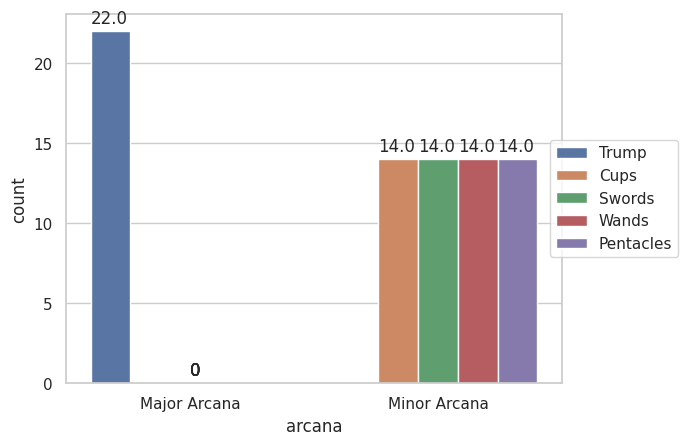

In [ ]:
ax = sns.countplot(x="arcana", hue="suit", data=cardsImgs)
ax.legend(loc='center right', bbox_to_anchor=(1.25, 0.5), ncol=1)
for p in ax.patches:
    ax.annotate('{}'.format(p.get_height()), (p.get_x(), p.get_height()+0.5))
ax

Your reading: Past, Present, Future on 2026-07-29


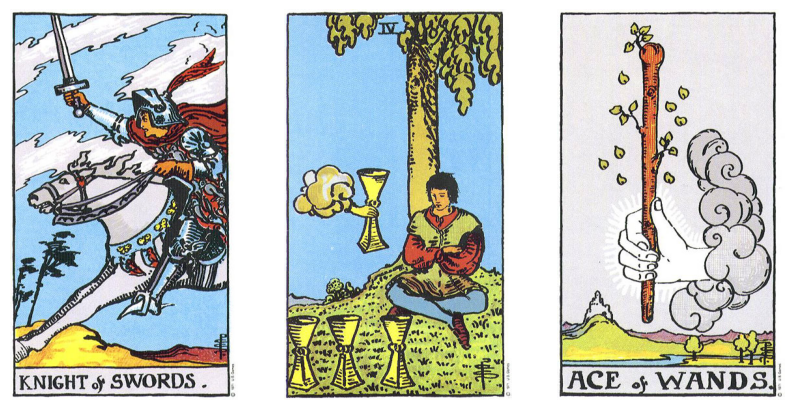

In [ ]:
import datetime
print("Your reading: Past, Present, Future on", datetime.datetime.now().date())

cards3 = cardsImgs.sample(n = 3).reset_index(drop=True)

plt.figure(figsize=(10,10))
c = 0
for i in cards3['img']:
    img = PIL.Image.open(f'/kaggle/input/tarot-json/cards/{i}')
    plt.subplot(1,3,c+1)
    plt.imshow(img)
    plt.axis('off')
    c+=1

plt.show()

In [ ]:
cardsImgs.info()